In [1]:
import json
import os

import astropy.units as u
import cmasher
import gc_utils
import h5py
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.cosmology import Planck18 as cosmo
from astropy.cosmology import z_at_value
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from scipy.interpolate import interp1d
from scipy.stats import gaussian_kde, norm
from sklearn.mixture import GaussianMixture


In [2]:
sim_lst = ["m12b", "m12c", "m12f", "m12i", "m12m"]
# sim_lst = ["m12i"]
sim_dir = "/Users/z5114326/Documents/simulations/"
# sim_dir = "/Volumes/Expansion/simulations/"


bands_dict = {"JC": ["v"], "SDSS": ["sdss_g", "sdss_z"]}

scmap = plt.get_cmap("tab10")
colors = [scmap(i) for i in np.linspace(0, 1, len(sim_lst))]
sim_colors = {sim: colors[i] for i, sim in enumerate(sim_lst)}

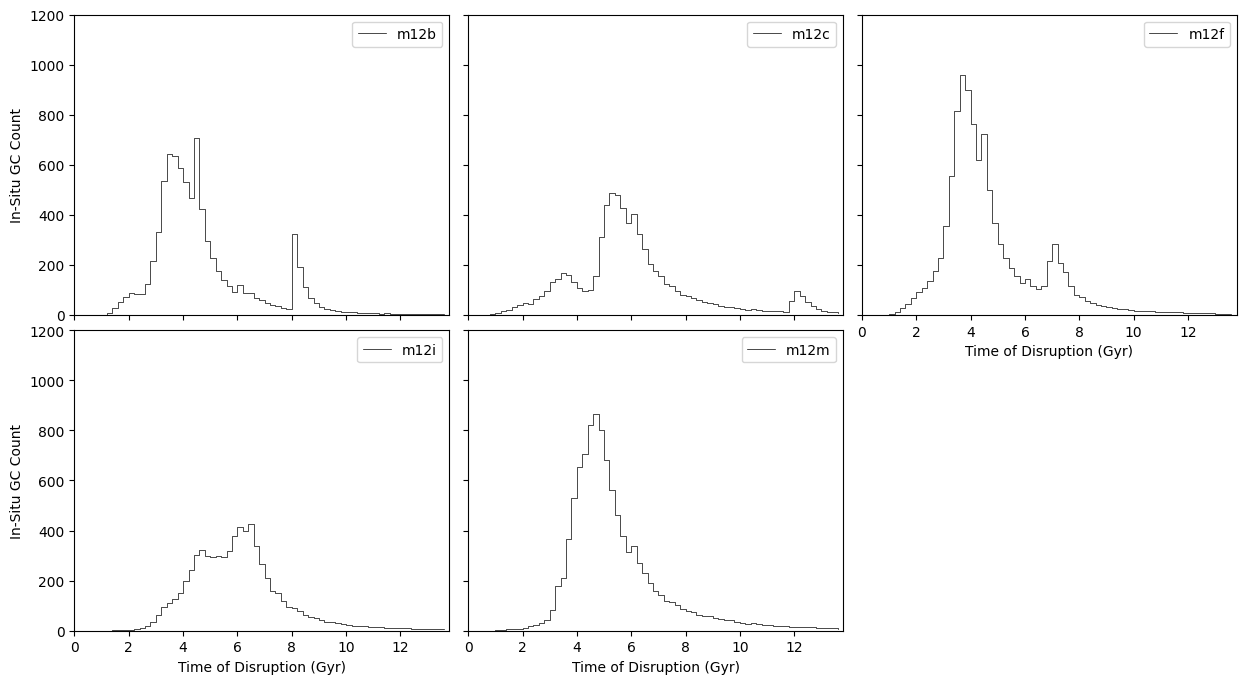

In [3]:
# sim = "m12b"

fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))
plt.subplots_adjust(hspace=0.05, wspace=0.05)

for i, ax in enumerate(axs.flatten()):
    if i == 5:
        ax.axis("off")
        continue

    sim = sim_lst[i]
    ghost_file = f"{sim_dir}{sim}/{sim}_ghosts.hdf5"
    ghost_data = h5py.File(ghost_file, "r")

    hist_dict = {"sum": None, "n": 0}
    bins = np.arange(0, 14, 0.2)

    all_tfors = []
    for it_id in ghost_data.keys():
        src_dat = ghost_data[it_id]["source"]
        insitu_msk = src_dat["grpid"][()] == 0
        tfors = src_dat["tdis"][insitu_msk]
        all_tfors.append(tfors)

        hssp, _ = np.histogram(tfors, bins=bins)

        if hist_dict["sum"] is None:
            hist_dict["sum"] = hssp.astype(float)
        else:
            hist_dict["sum"] += hssp
        hist_dict["n"] += 1

    binsum = hist_dict["sum"] / hist_dict["n"]
    ax.step(bins[:-1], binsum, where="post", color="k", label=sim, lw=0.5)
    ax.legend(loc="upper right")

    ax.set_xlim(0, 13.8)
    ax.set_ylim(0, 1200)

    if i in [2, 3, 4]:
        ax.set_xlabel("Time of Disruption (Gyr)")

    if i in [0, 1]:
        ax.set_xticklabels([])

    if i in [0, 3]:
        ax.set_ylabel("In-Situ GC Count")

    if i in [1, 2, 4]:
        ax.set_yticklabels([])

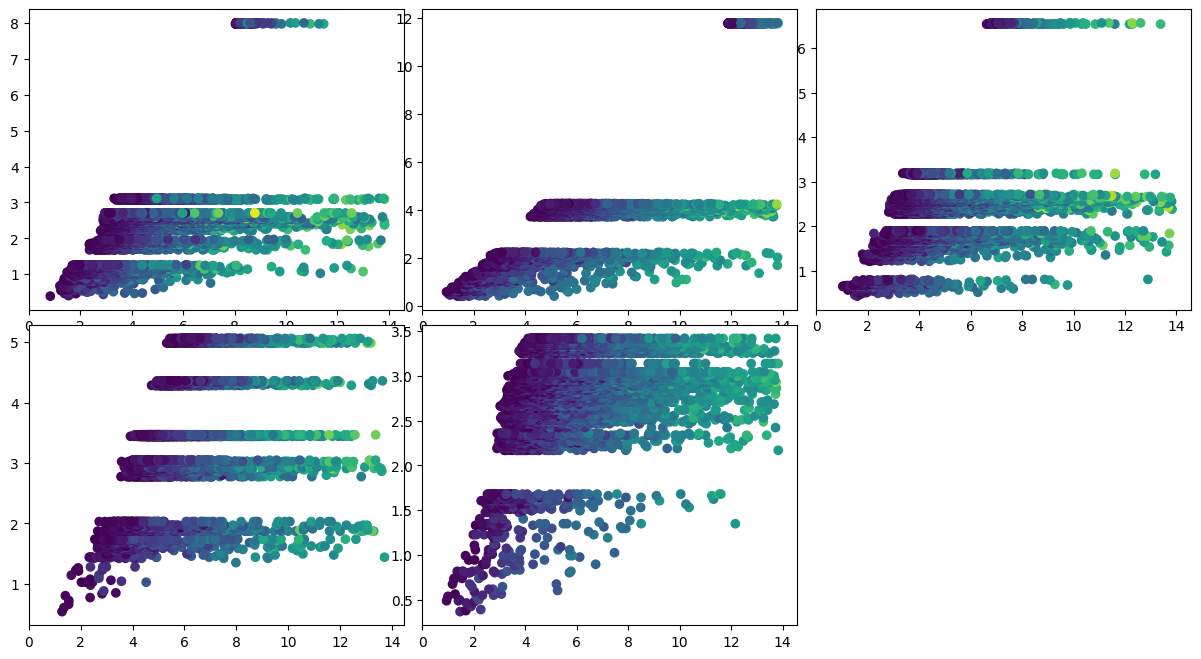

In [4]:
# sim = "m12b"

fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))
plt.subplots_adjust(hspace=0.05, wspace=0.05)

for i, ax in enumerate(axs.flatten()):
    if i == 5:
        ax.axis("off")
        continue

    sim = sim_lst[i]
    ghost_file = f"{sim_dir}{sim}/{sim}_ghosts.hdf5"
    ghost_data = h5py.File(ghost_file, "r")

    hist_dict = {"sum": None, "n": 0}
    bins = np.arange(0, 14, 0.2)

    it_id = "it001"
    src_dat = ghost_data[it_id]["source"]
    insitu_msk = src_dat["grpid"][()] == 0
    tfor = src_dat["tfor"][insitu_msk]
    tdis = src_dat["tdis"][insitu_msk]
    mfor = src_dat["logm_tfor"][insitu_msk]

    ax.scatter(tdis, tfor, c=mfor)
    ax.set_xlim(0)

    #     hssp, _ = np.histogram(tfors, bins=bins)

    #     if hist_dict["sum"] is None:
    #         hist_dict["sum"] = hssp.astype(float)
    #     else:
    #         hist_dict["sum"] += hssp
    #     hist_dict["n"] += 1

    # binsum = hist_dict["sum"] / hist_dict["n"]
    # ax.step(bins[:-1], binsum, where="post", color="k", label=sim, lw=0.5)
    # ax.legend(loc="upper right")

    # ax.set_xlim(0, 13.8)
    # ax.set_ylim(0, 1200)

    # if i in [2, 3, 4]:
    #     ax.set_xlabel("Time of Disruption (Gyr)")

    # if i in [0, 1]:
    #     ax.set_xticklabels([])

    # if i in [0, 3]:
    #     ax.set_ylabel("In-Situ GC Count")

    # if i in [1, 2, 4]:
    #     ax.set_yticklabels([])

In [5]:
sim = "m12i"

ghost_file = f"{sim_dir}{sim}/{sim}_ghosts.hdf5"
ghost_data = h5py.File(ghost_file, "r")

it_id = "it001"
src_dat = ghost_data[it_id]["source"]
insitu_msk = src_dat["grpid"][()] == 0
ages = 13.8 - src_dat["tfor"][insitu_msk]
smsk = src_dat["s_flag"][insitu_msk].astype(bool)

bins = np.arange(0, 13.9, 0.1)
bin_idx = np.digitize(ages, bins)

bin_centers = 0.5 * (bins[:-1] + bins[1:])
arr = np.full(len(bin_centers), np.nan)

for i in range(1, len(bins)):
    mask = bin_idx == i
    if np.any(mask):
        smsk_i = smsk[mask]
        arr[i - 1] = np.sum(smsk_i) / len(smsk_i)

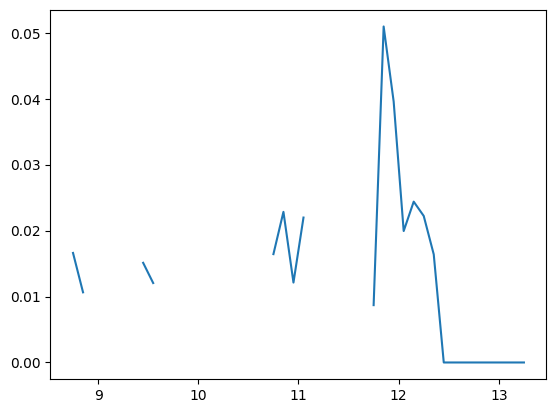

In [6]:
plt.plot(bin_centers, arr)

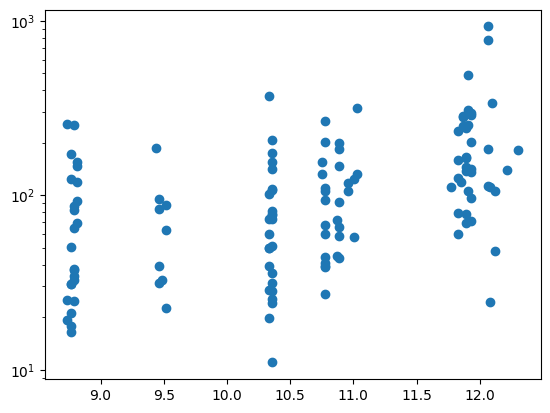

In [7]:
sim = "m12i"

ghost_file = f"{sim_dir}{sim}/{sim}_ghosts.hdf5"
ghost_data = h5py.File(ghost_file, "r")

it_id = "it001"
src_dat = ghost_data[it_id]["source"]
insitu_msk = src_dat["grpid"][()] == 0
smsk = src_dat["s_flag"][()].astype(bool)


ages = 13.8 - src_dat["tfor"][smsk & insitu_msk]
pz0 = src_dat["torb_600"][smsk & insitu_msk]


plt.scatter(ages, pz0)
plt.yscale("log")

Text(0.5, 0, 'log Formation Mass')

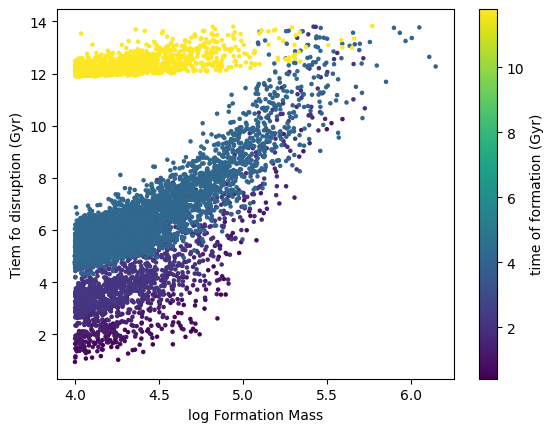

In [8]:
sim = "m12c"

ghost_file = f"{sim_dir}{sim}/{sim}_ghosts.hdf5"
ghost_data = h5py.File(ghost_file, "r")

it_id = "it001"
src_dat = ghost_data[it_id]["source"]
insitu_msk = src_dat["grpid"][()] == 0
smsk = src_dat["s_flag"][()].astype(bool)


mas0 = src_dat["logm_tfor"][~smsk & insitu_msk]
tdis = src_dat["tdis"][~smsk & insitu_msk]
tfor = src_dat["tfor"][~smsk & insitu_msk]


plt.scatter(mas0, tdis, c=tfor, s=5)
plt.colorbar(label="time of formation (Gyr)")
plt.ylabel("Tiem fo disruption (Gyr)")
plt.xlabel("log Formation Mass")

In [9]:
sim = "m12m"

ghost_file = f"{sim_dir}{sim}/{sim}_ghosts.hdf5"
ghost_data = h5py.File(ghost_file, "r")

it_id = "it001"
src_dat = ghost_data[it_id]["source"]
insitu_msk = src_dat["grpid"][()] == 0
fehs = src_dat["feh"][insitu_msk]
smsk = src_dat["s_flag"][insitu_msk].astype(bool)

bins = np.arange(-3.4, 0, 0.2)
bin_idx = np.digitize(fehs, bins)

vxyz = src_dat["vxyz_snap600"][insitu_msk]
pxyz = src_dat["pxyz_snap600"][insitu_msk]

# Cartesian positions and velocities
x, y, z = pxyz.T
vx, vy, vz = vxyz.T

# Spherical coordinates
r = np.sqrt(x**2 + y**2 + z**2)
theta = np.arccos(z / r)  # polar angle [0, pi]
phi = np.arctan2(y, x)  # azimuthal angle [-pi, pi]

# Velocity components in spherical coordinates
vr = (x * vx + y * vy + z * vz) / r

vtheta = (z * (x * vx + y * vy) - (x**2 + y**2) * vz) / (r * np.sqrt(x**2 + y**2))

vphi = (x * vy - y * vx) / (x**2 + y**2)

# Stack if wanted
psph = np.column_stack([r, theta, phi])
vsph = np.column_stack([vr, vtheta, vphi])


bin_centers = 0.5 * (bins[:-1] + bins[1:])
arr_s = np.full(len(bin_centers), np.nan)
arr_d = np.full(len(bin_centers), np.nan)


for i in range(1, len(bins)):
    mask = bin_idx == i
    if np.any(mask):
        smk_i = smsk[mask]
        arr_s[i - 1] = np.median(vphi[mask][smk_i])
        arr_d[i - 1] = np.median(vphi[mask][~smk_i])

/Users/z5114326/Documents/GitHub/ghost_accretions/.venv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/z5114326/Documents/GitHub/ghost_accretions/.venv/lib/python3.11/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


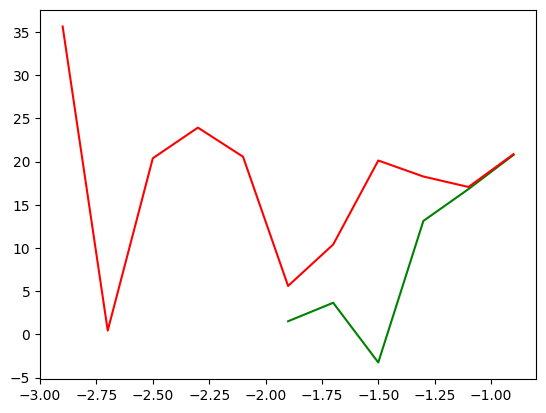

In [10]:
plt.plot(bin_centers, arr_s, c="g")
plt.plot(bin_centers, arr_d, c="r")

In [11]:
smsk

array([False, False, False, ..., False, False,  True], shape=(12743,))

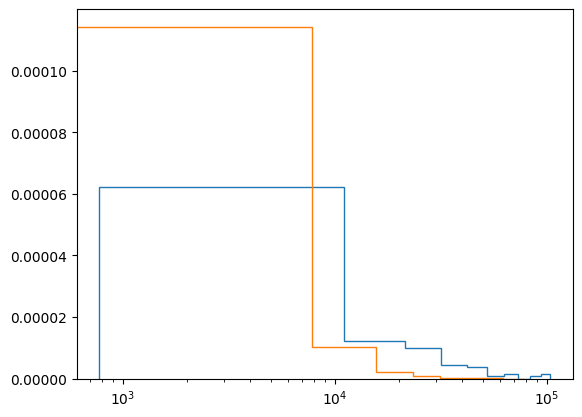

In [29]:
sim = "m12i"

ghost_file = f"{sim_dir}{sim}/{sim}_ghosts.hdf5"
ghost_data = h5py.File(ghost_file, "r")

it_id = "it001"
src_dat = ghost_data[it_id]["source"]
insitu_msk = src_dat["grpid"][()] == 0
fehs = src_dat["feh"][insitu_msk]
smsk = src_dat["s_flag"][insitu_msk].astype(bool)

tide = src_dat["tideig.avg"][insitu_msk]
tfor = src_dat["tfor"][insitu_msk]

tides = tide[smsk]
tided = tide[~smsk]

plt.hist(tides, histtype="step", density=True)
plt.hist(tided, histtype="step", density=True)
plt.xscale("log")

# bins = np.arange(0, 6.5, 0.1)

# bin_idx = np.digitize(tfor, bins)

# bin_centers = 0.5 * (bins[:-1] + bins[1:])
# tides = np.full(len(bin_centers), np.nan)
# tided = np.full(len(bin_centers), np.nan)

# for i in range(1, len(bins)):
#     mask = bin_idx == i
#     if np.any(mask):
#         smsk_i = smsk[mask]
#         # mean_circ[i - 1] = circs[mask].mean()
#         tides[i - 1] = np.mean(tide[mask][smsk_i])
#         tided[i - 1] = np.mean(tide[mask][~smsk_i])

# plt.plot(bin_centers, tides, c="g")
# plt.plot(bin_centers, tided, c="orange")
# plt.yscale("log")